In [1]:
import torch
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import PolynomialLR
from torch.utils.data import WeightedRandomSampler
from torchvision.transforms import v2

import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm.notebook import tqdm
import json
import numpy as np
###IE###
%load_ext autoreload
%autoreload 2
from utils.helpers import  plot_some_images ,read_images , pre_hard_skeletonize , pre_soft_skeletonize,compute_confution_matrix
from utils.preprocessing import WhiteTopHat , CLAHE , normalize_xca
from utils.dataset import  UnetDataset , ValidUnetDataset
from models.nnunet import nnUnet
from models.nnunet_blocks import nnUnetv2
from utils.losses import UnetLoss
from utils.recorder import HistoryRecorder
from logger import save_full_report
from trainer import trainer
###SS###

# Training

In [ ]:
args = {
    "base_path" : "../arcade/nnUnet_dataset/syntax",
    "in_c" : 1,
    "base_channel" :32,
    "image_shape" : (224,224),
    "class_count" : 26 ,
    "attention" : False,
    "k":40,
    "batch_size" : 10,
    "num_workers" : 10,
    "device" : "cuda" if torch.cuda.is_available() else "cpu",
    "lr" : 0.01,
    "momentum" : 0.99,
    "weight_decay" : 3e-5,
    "epcohs":200,
    "f_int_scale" : 2,
    "full_report_cycle" : 10,
    "max_channels":512,
    "input_channels":1,
    "loss_type":"tversky loss",
    "alpha":0.3,
    "beta":0.7,
    "t_gamma":2.00,
    "f_gamma":2.0,
    "f_loss_scale":1,
    "loss_coefs":{"CE":0.5,"Second":1.0},
    "output_base_path" : "./outputs",
    "name" : "NoAttention7-DSV-tev-mistmatch_test",
    "deep_super_vision" : True,
    "f_alpha":None
}
class_map = {
    1: '1',2: '2', 3: '3',4: '4',
    5: '5',6: '6',7: '7',8: '8',
    9: '9',10: '9a',11: '10',12: '10a',
    13: '11',14: '12',15: '12a',16: '13',
    17: '14',18: '14a',19: '15',20: '16',
    21: '16a',22: '16b',23: '16c',
    24: '12b',25: '14b'
}
train_class_counts = [
    1000,374,375,369,303,525,525,
    340,310,198,70,21,1,320,61,
    129,305,107,49,38,232,43,48,31,63,127
]
# losses_keys = ["total loss","FCE loss",args["loss_type"]]
losses_keys = ["total loss","CE loss",args["loss_type"]]
out_counts = 6 if args["deep_super_vision"] else 1
loss_weights = [1/(2**i) for i in range(out_counts)]
loss_weights

[1.0, 0.5, 0.25, 0.125, 0.0625, 0.03125]

In [3]:
# with open("./data/train_class_counts.json","r") as f:
#     train_class_counts = json.load(f)

# b = 0.999999

# counts = [0]*(len(train_class_counts))
# for k,v in train_class_counts.items():
#     counts[int(k)] = int(v)
# counts = np.array(counts,dtype=np.float64)

# f_alpha = (1-b)/(1-np.power(b,counts))
# f_alpha = f_alpha / f_alpha.sum()
# f_alpha[12] = 0.25
# # args["f_alpha"] = f_alpha.tolist()
# args["f_alpha"]=None
# args["f_alpha"]

In [4]:
# b=0.999
# # f_alpha = (1-b)/(1-np.power(b,train_class_counts))
# total = np.sum(train_class_counts)
# f_alpha = np.log(total/np.array(train_class_counts))
# f_alpha = (f_alpha / f_alpha.mean()).tolist()
# f_alpha
# args["f_alpha"] = f_alpha
# args["f_alpha"][0] = 0.1
# f_alpha
args["f_alpha"]=None

In [5]:
# pre_soft_skeletonize(args["base_path"],output_path=args["base_path"],batch_size=10,k=40)

In [6]:
train_transforms = A.Compose([
    A.Resize(*args["image_shape"]),
    A.Downscale(
        scale_range=[0.7, 1],
        interpolation_pair={"downscale": 0, "upscale": 0},
        p=0.4
    ),
    A.GaussNoise(
        std_range=[0.0, 0.1],
        mean_range=[0, 0],
        per_channel=True,
        noise_scale_factor=1,
        p=0.4
    ),
    A.GaussianBlur(
        sigma_limit=[1.0,1.5],
        blur_limit = (3,7),
        p=0.4
    ),
    
    A.RandomBrightnessContrast(
        brightness_limit=(-0.15, 0.15 ),
        contrast_limit=(-0.15, 0.15 ),  
        brightness_by_max=True,
        p=0.3
    ),
    A.RandomGamma(
        gamma_limit=(90, 120), 
        p=0.3
    ),
    # A.Affine(
    #     scale=(0.7, 1.4),  
    #     translate_percent=(0, 0),
    #     rotate=0,               
    #     shear=0,                 
    #     fit_output=False, 
    #     p=0.3
    # ),
    A.Rotate(limit=[-90,90], p=0.4, fill_mask = 0),
    # A.Rotate(limit=-30, p=0.4, fill_mask = 0),
    A.HorizontalFlip(p=0.4),
    A.VerticalFlip(p=0.4),
    A.Lambda(image=normalize_xca)
    ]
)
test_transforms = A.Compose([
    A.Resize(*args["image_shape"]),
    A.Lambda(image=normalize_xca),
    ToTensorV2()
    ]  
)
# train_preprocess = v2.Compose([
#     WhiteTopHat(kernel_size=(50,50)),
#     CLAHE()
    
# ])
train_preprocess = None


In [7]:
import numpy as np

In [8]:
ls= np.array([14,2,3])
g=np.array([0,1,1])
u=np.unique(g)
ls[u]

array([14,  2])

In [9]:
def make_dataloader(data,args,valid=False,sampler_weights=None):
    if(sampler_weights is not None):
        print("using weighted sampler here")
        sampler = WeightedRandomSampler(sampler_weights, len(sampler_weights))
        dataloader = DataLoader(
            data,
            batch_size = args["batch_size"] ,
            num_workers = args["num_workers"] ,
            pin_memory=True,
            shuffle=False,
            sampler=sampler
        )
        
    else : 
        if(valid):
            print("valid with no sampler")
            dataloader = DataLoader(
                data,
                batch_size = args["batch_size"] ,
                num_workers = args["num_workers"] ,
                pin_memory=True,
                shuffle=False,
            )
        else : 
            print("train with no sampler")
            dataloader = DataLoader(
                data,
                batch_size = args["batch_size"] ,
                num_workers = args["num_workers"] ,
                pin_memory=True,
                shuffle=True
            )
    return dataloader

In [ ]:

train_images,sampler_weights = read_images(
    base_path = args["base_path"],
    preprocessor = train_preprocess,
    part = "train",
    train_class_counts=np.array(train_class_counts)
)
valid_images = read_images(
    base_path = args["base_path"],
    preprocessor = train_preprocess,
    part = "val",
    train_class_counts=None
)
train_ds = UnetDataset(transform = train_transforms,data = train_images,base_size=args["image_shape"][0],out_counts=out_counts)
valid_ds = ValidUnetDataset(transform = test_transforms,data = train_images)

train_loader = make_dataloader(train_ds,args,valid=False,sampler_weights=sampler_weights)
valid_loader = make_dataloader(valid_ds,args,valid=True,sampler_weights=None)

max count is :  525
NOTE : preprocessor is not defined . no preprocessing will be used !


  0%|          | 0/1000 [00:00<?, ?it/s]

NOTE : preprocessor is not defined . no preprocessing will be used !


  0%|          | 0/200 [00:00<?, ?it/s]

using weighted sampler here
valid with no sampler


In [11]:
# plot_some_images(train_images, train_transforms, image_counts=36, fig_shape=(6,6), base_transforms=test_transforms)

In [12]:
model = nnUnet(args).to(args["device"])
loss_fn = UnetLoss(args)
# optimizer = torch.optim.Adam(model.parameters(), lr=args["lr"])
optimizer = torch.optim.SGD(
    model.parameters(),
    momentum=args["momentum"],
    lr=args["lr"],
    nesterov=True,
    weight_decay=args["weight_decay"]
)
lr_sch = PolynomialLR(optimizer=optimizer,total_iters=args["epcohs"],power=0.9)
recorder = HistoryRecorder(losses_keys=losses_keys,class_maps =class_map)

best_model =trainer(
    args=args,
    recorder = recorder,
    model = model,
    optimizer = optimizer,
    loss_fn = loss_fn,
    train_loader = train_loader,
    valid_loader = valid_loader,
    loss_weights=loss_weights,
    lr_sch = lr_sch
)

number of layers : 6
encoder settings :  [32, 64, 128, 256, 512, 512]
bottle-neck settings :  1024
decoder settings :  [1024, 512, 256, 128, 64]
head settings :  26
loss is set to tversky


  0%|          | 0/200 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

current lr : 0.01
train ==> epcoh (0)
total loss : 2.536439335346222 - CE loss : 0.5926026806235314 - tversky loss : 1.9438366270065308

train avg metrics for epoch 0 :
avg dice : 0.0005302675198566854 - avg precision : 0.0011844511488015997 - avg recall : 0.0010873450951476116
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (0)
total loss : 1.0796468377113342 - CE loss : 0.10017525516450405 - tversky loss : 0.9794715970754624

valid avg metrics for epoch 0 :
avg dice : 2.2012348248421493e-12 - avg precision : 0.0 - avg recall : 0.0
------------------------------------------------------------
New Best! : dice = 2.201234854115608e-12


  0%|          | 0/100 [00:00<?, ?it/s]

...

current lr : 0.0002283
train ==> epcoh (197)
total loss : 0.41498587489128114 - CE loss : 0.06423322655260563 - tversky loss : 0.3507526448369026

train avg metrics for epoch 197 :
avg dice : 0.7486562609672547 - avg precision : 0.6966342186927795 - avg recall : 0.8105852293968201
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (197)
total loss : 0.47064161896705625 - CE loss : 0.06144238002598286 - tversky loss : 0.40919923931360247

valid avg metrics for epoch 197 :
avg dice : 0.4254996429389303 - avg precision : 0.45051628664135934 - avg recall : 0.423354921862483
------------------------------------------------------------


  0%|          | 0/100 [00:00<?, ?it/s]

current lr : 0.0001585
train ==> epcoh (198)
total loss : 0.36138252049684527 - CE loss : 0.06399123311042786 - tversky loss : 0.29739128679037097

train avg metrics for epoch 198 :
avg dice : 0.7529239749908447 - avg precision : 0.6979123663902282 - avg recall : 0.8191101861000061
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (198)
total loss : 0.46891412138938904 - CE loss : 0.06228332594037056 - tversky loss : 0.4066307932138443

valid avg metrics for epoch 198 :
avg dice : 0.42275040730889485 - avg precision : 0.44043332677334546 - avg recall : 0.4274589981883764
------------------------------------------------------------


  0%|          | 0/100 [00:00<?, ?it/s]

current lr : 8.493e-05
train ==> epcoh (199)
total loss : 0.3943419969081879 - CE loss : 0.06524006836116314 - tversky loss : 0.32910192728042603

train avg metrics for epoch 199 :
avg dice : 0.7463984298706055 - avg precision : 0.692206106185913 - avg recall : 0.8115293455123901
<=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=><=>
valid ==> epcoh (199)
total loss : 0.4699078038334846 - CE loss : 0.0622031332924962 - tversky loss : 0.40770466923713683

valid avg metrics for epoch 199 :
avg dice : 0.42386594042237447 - avg precision : 0.44550250556319954 - avg recall : 0.42576806925237176
1 => dice : 0.7775937914848328 p : 0.7543691992759705 , r : 0.8022938966751099
2 => dice : 0.7311383485794067 p : 0.7571293711662292 , r : 0.7068725228309631
3 => dice : 0.7234846949577332 p : 0.6782956123352051 , r : 0.775124728679657
4 => dice : 0.6469098329544067 p : 0.5881546139717102 , r : 0.7187069654464722
5 => dice : 0.7506603598594666 p : 0.7673934698104858 , r : 0.734641432762146
6 =>

Save Model
Saving Memory
Saving All Plots


  0%|          | 0/20 [00:00<?, ?it/s]

Saving Examples


  0%|          | 0/18 [00:00<?, ?it/s]

Saving Verbal Results
Copying Notebook To Results
builfding kaggle project


100%|██████████| 9/9 [00:00<00:00, 2997.36it/s]


processing ./utils/dataset.py
processing ./utils/helpers.py
processing ./logger.py
processing ./utils/preprocessing.py
processing ./utils/recorder.py
processing ./models/costume_nnunet_blocks.py
processing ./models/nnunet.py
processing ./utils/losses.py
processing ./trainer.py


100%|██████████| 1/1 [00:00<00:00,  4.82it/s]

processing ./temp_script.py


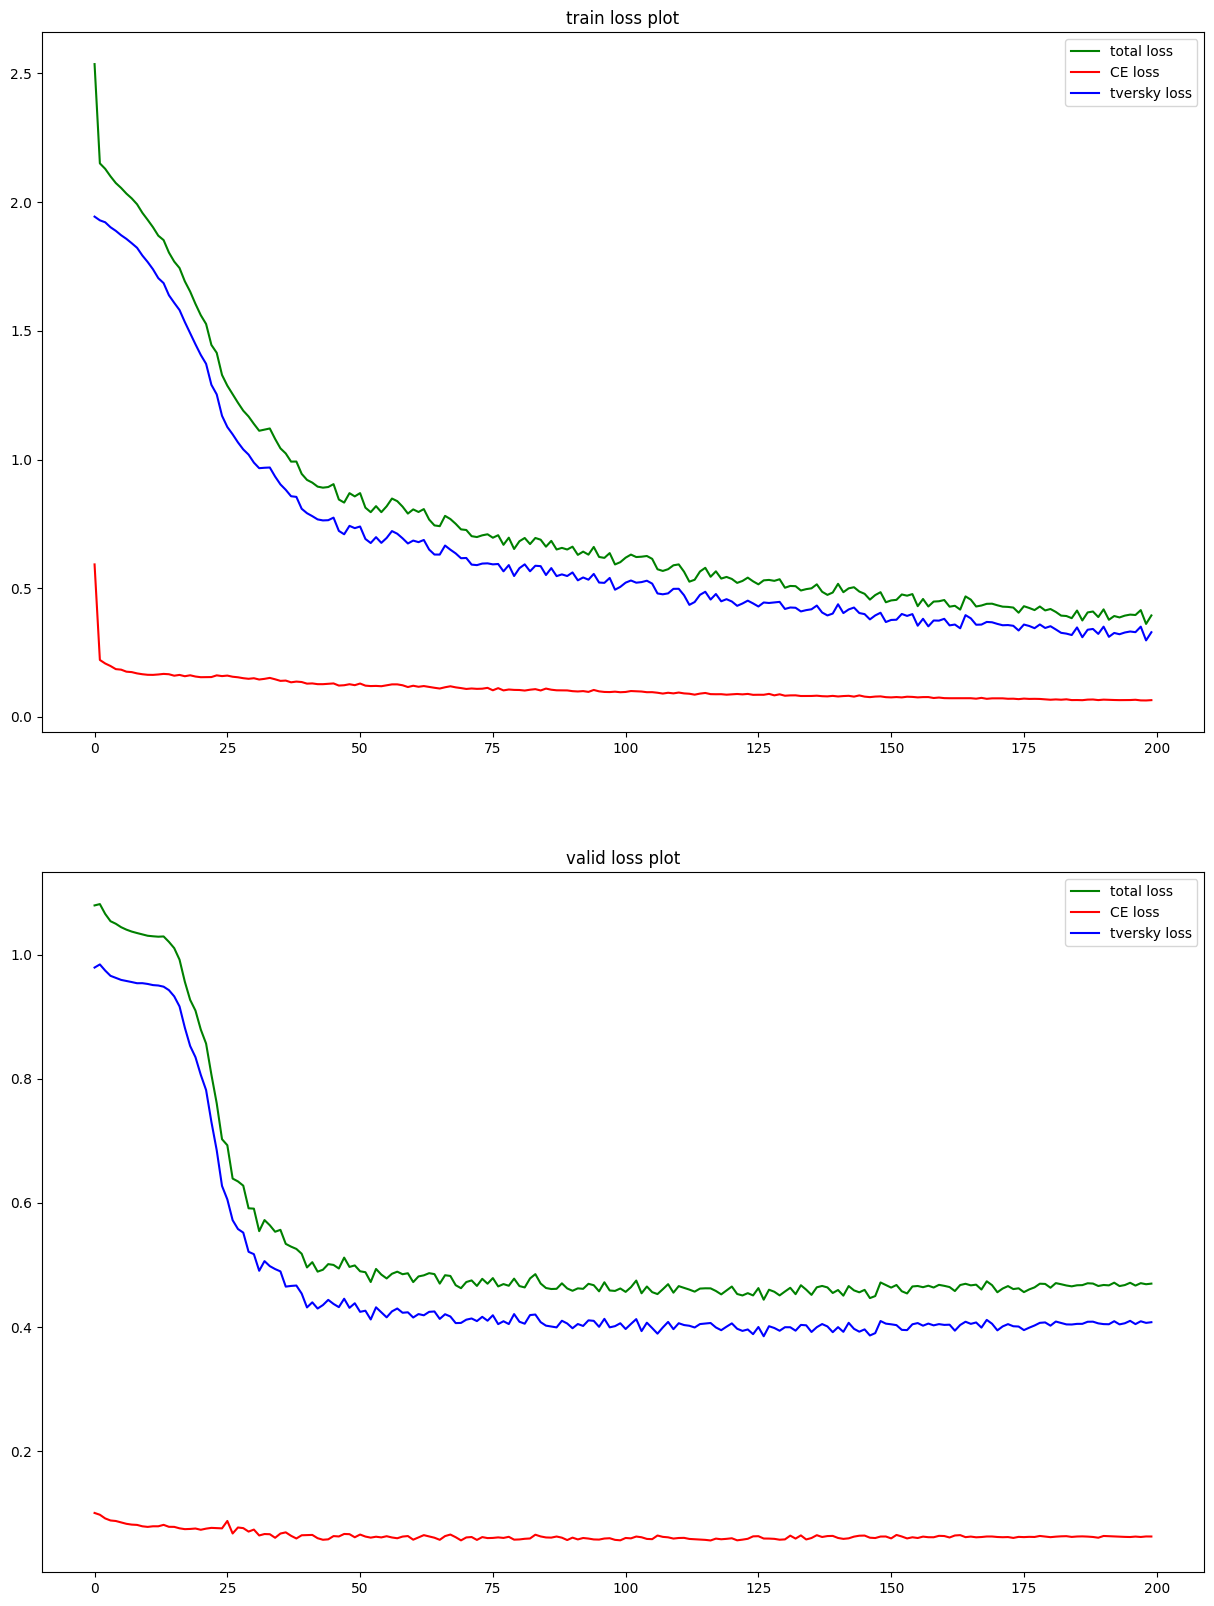

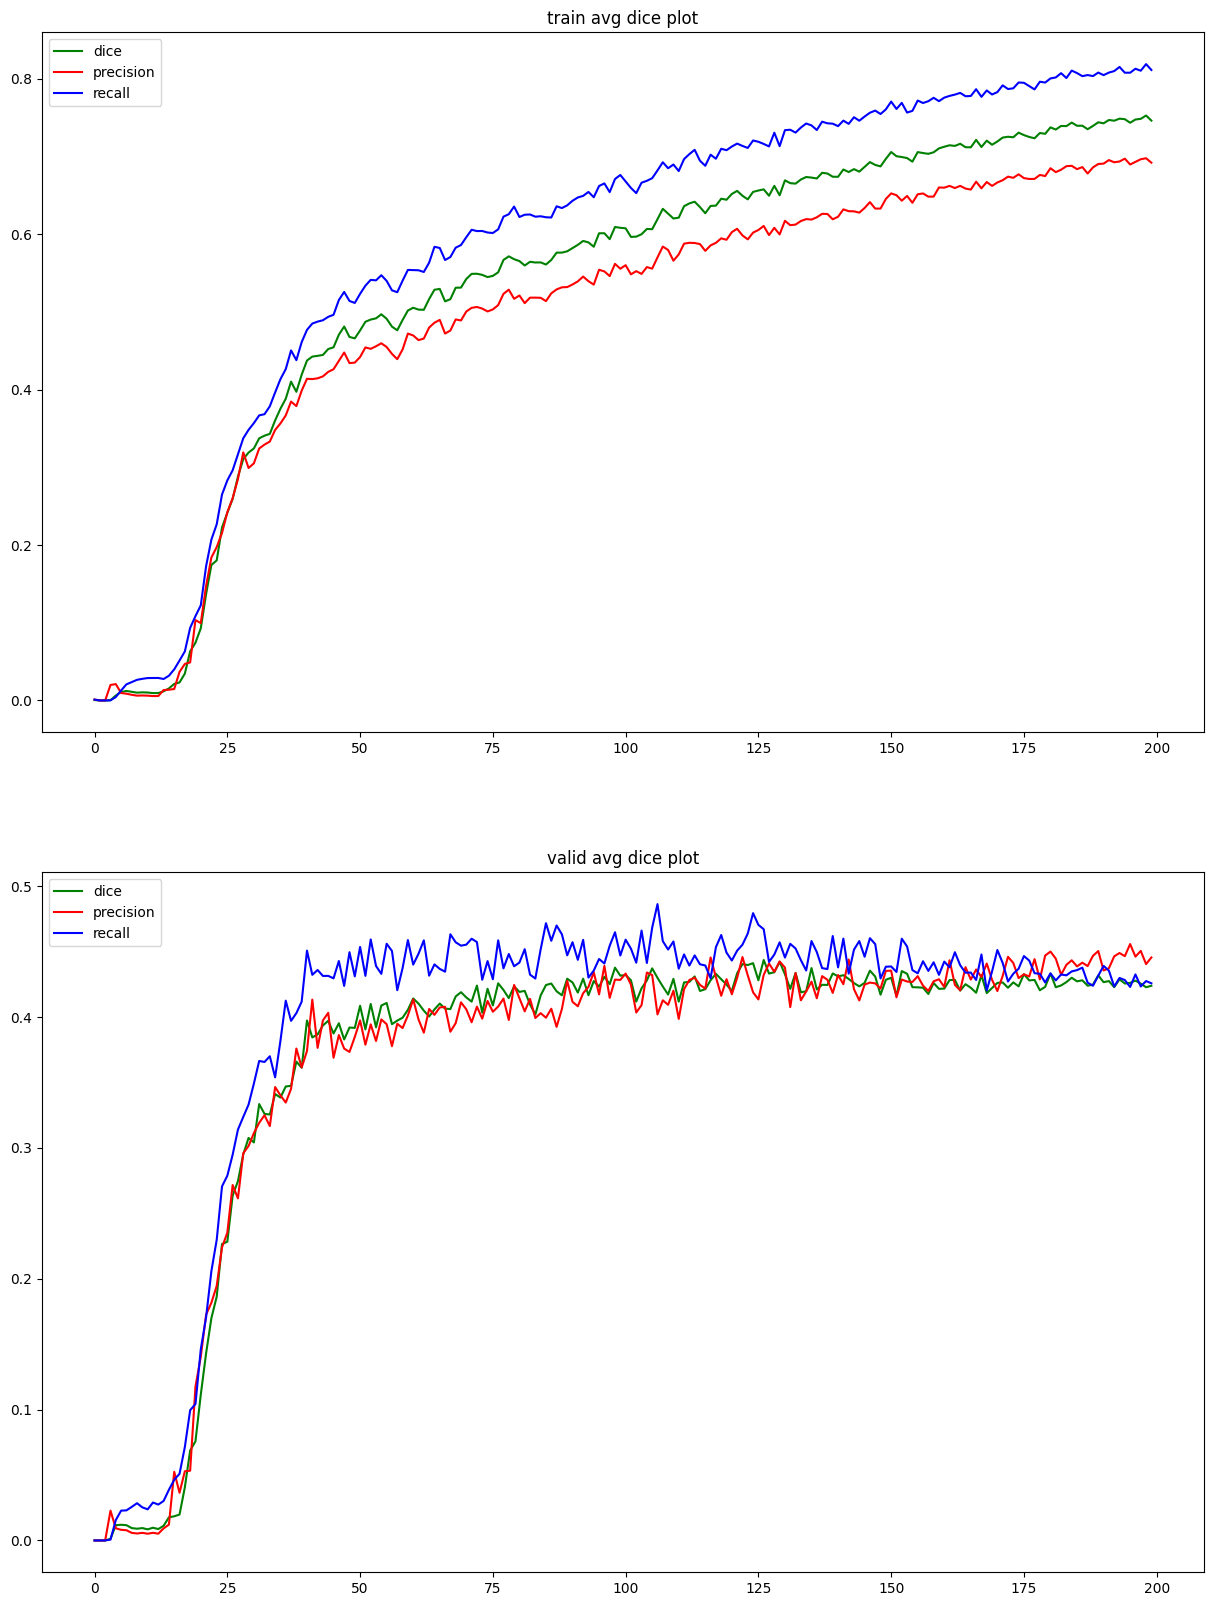

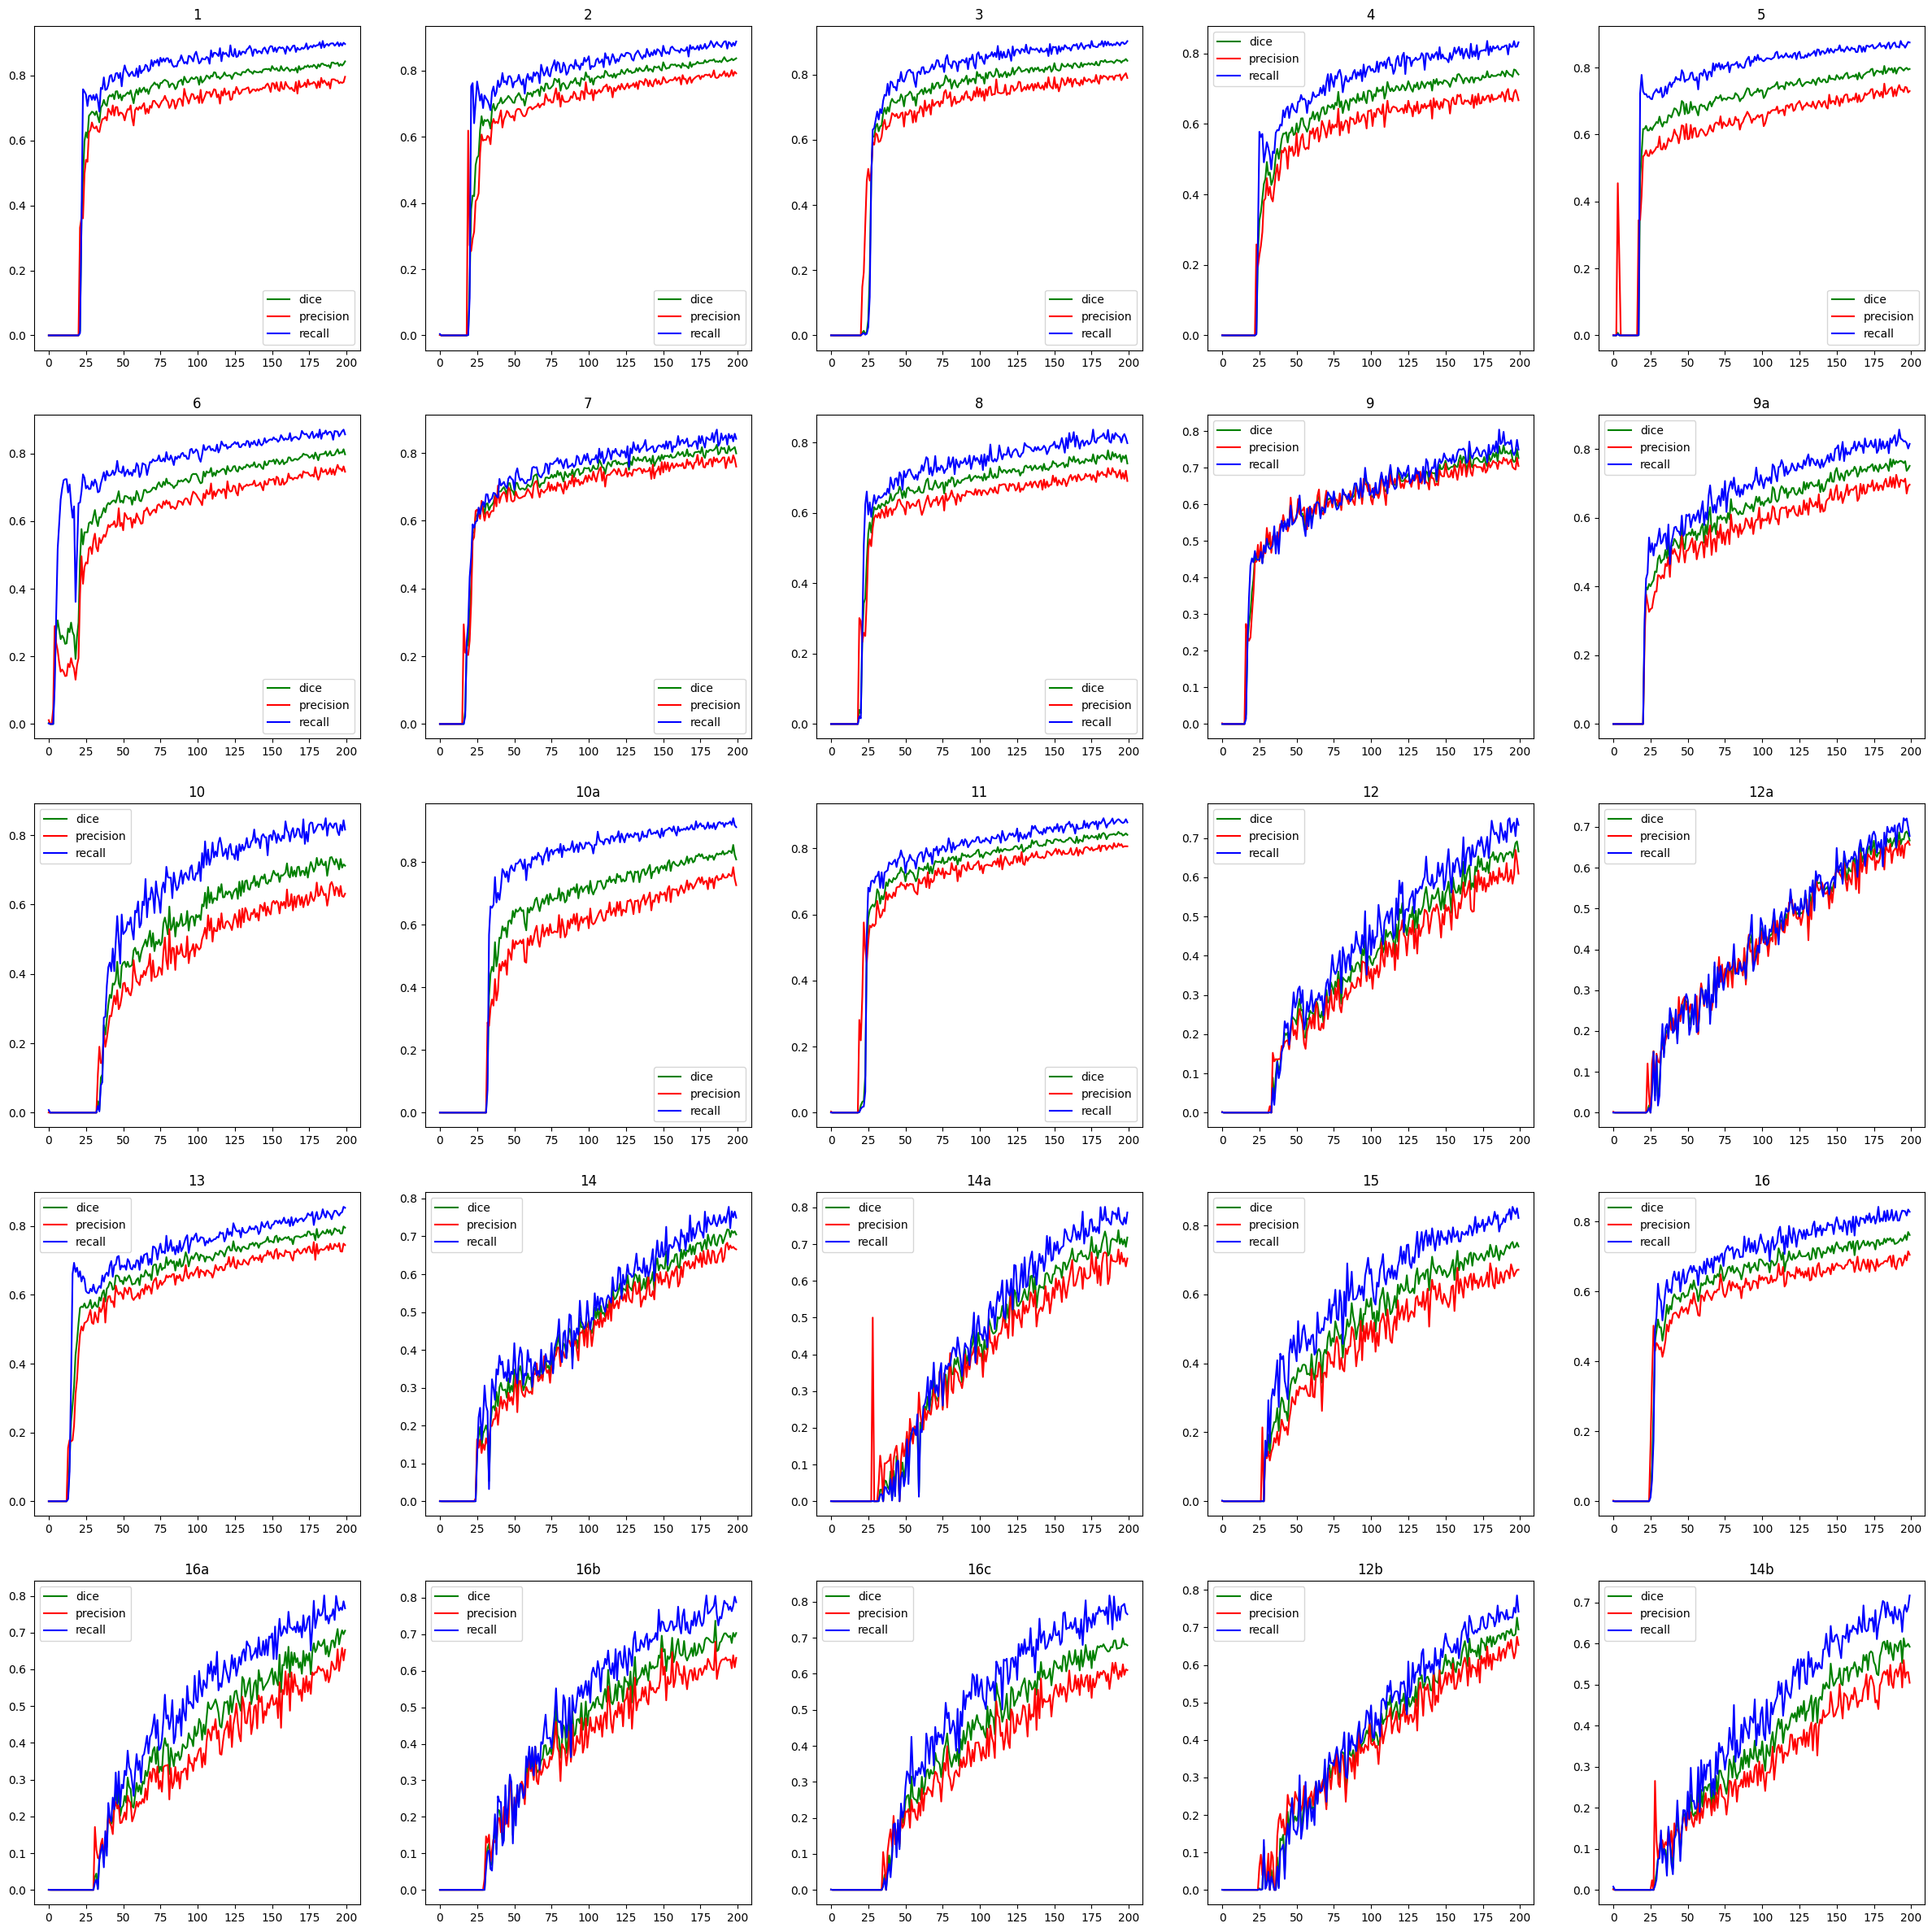

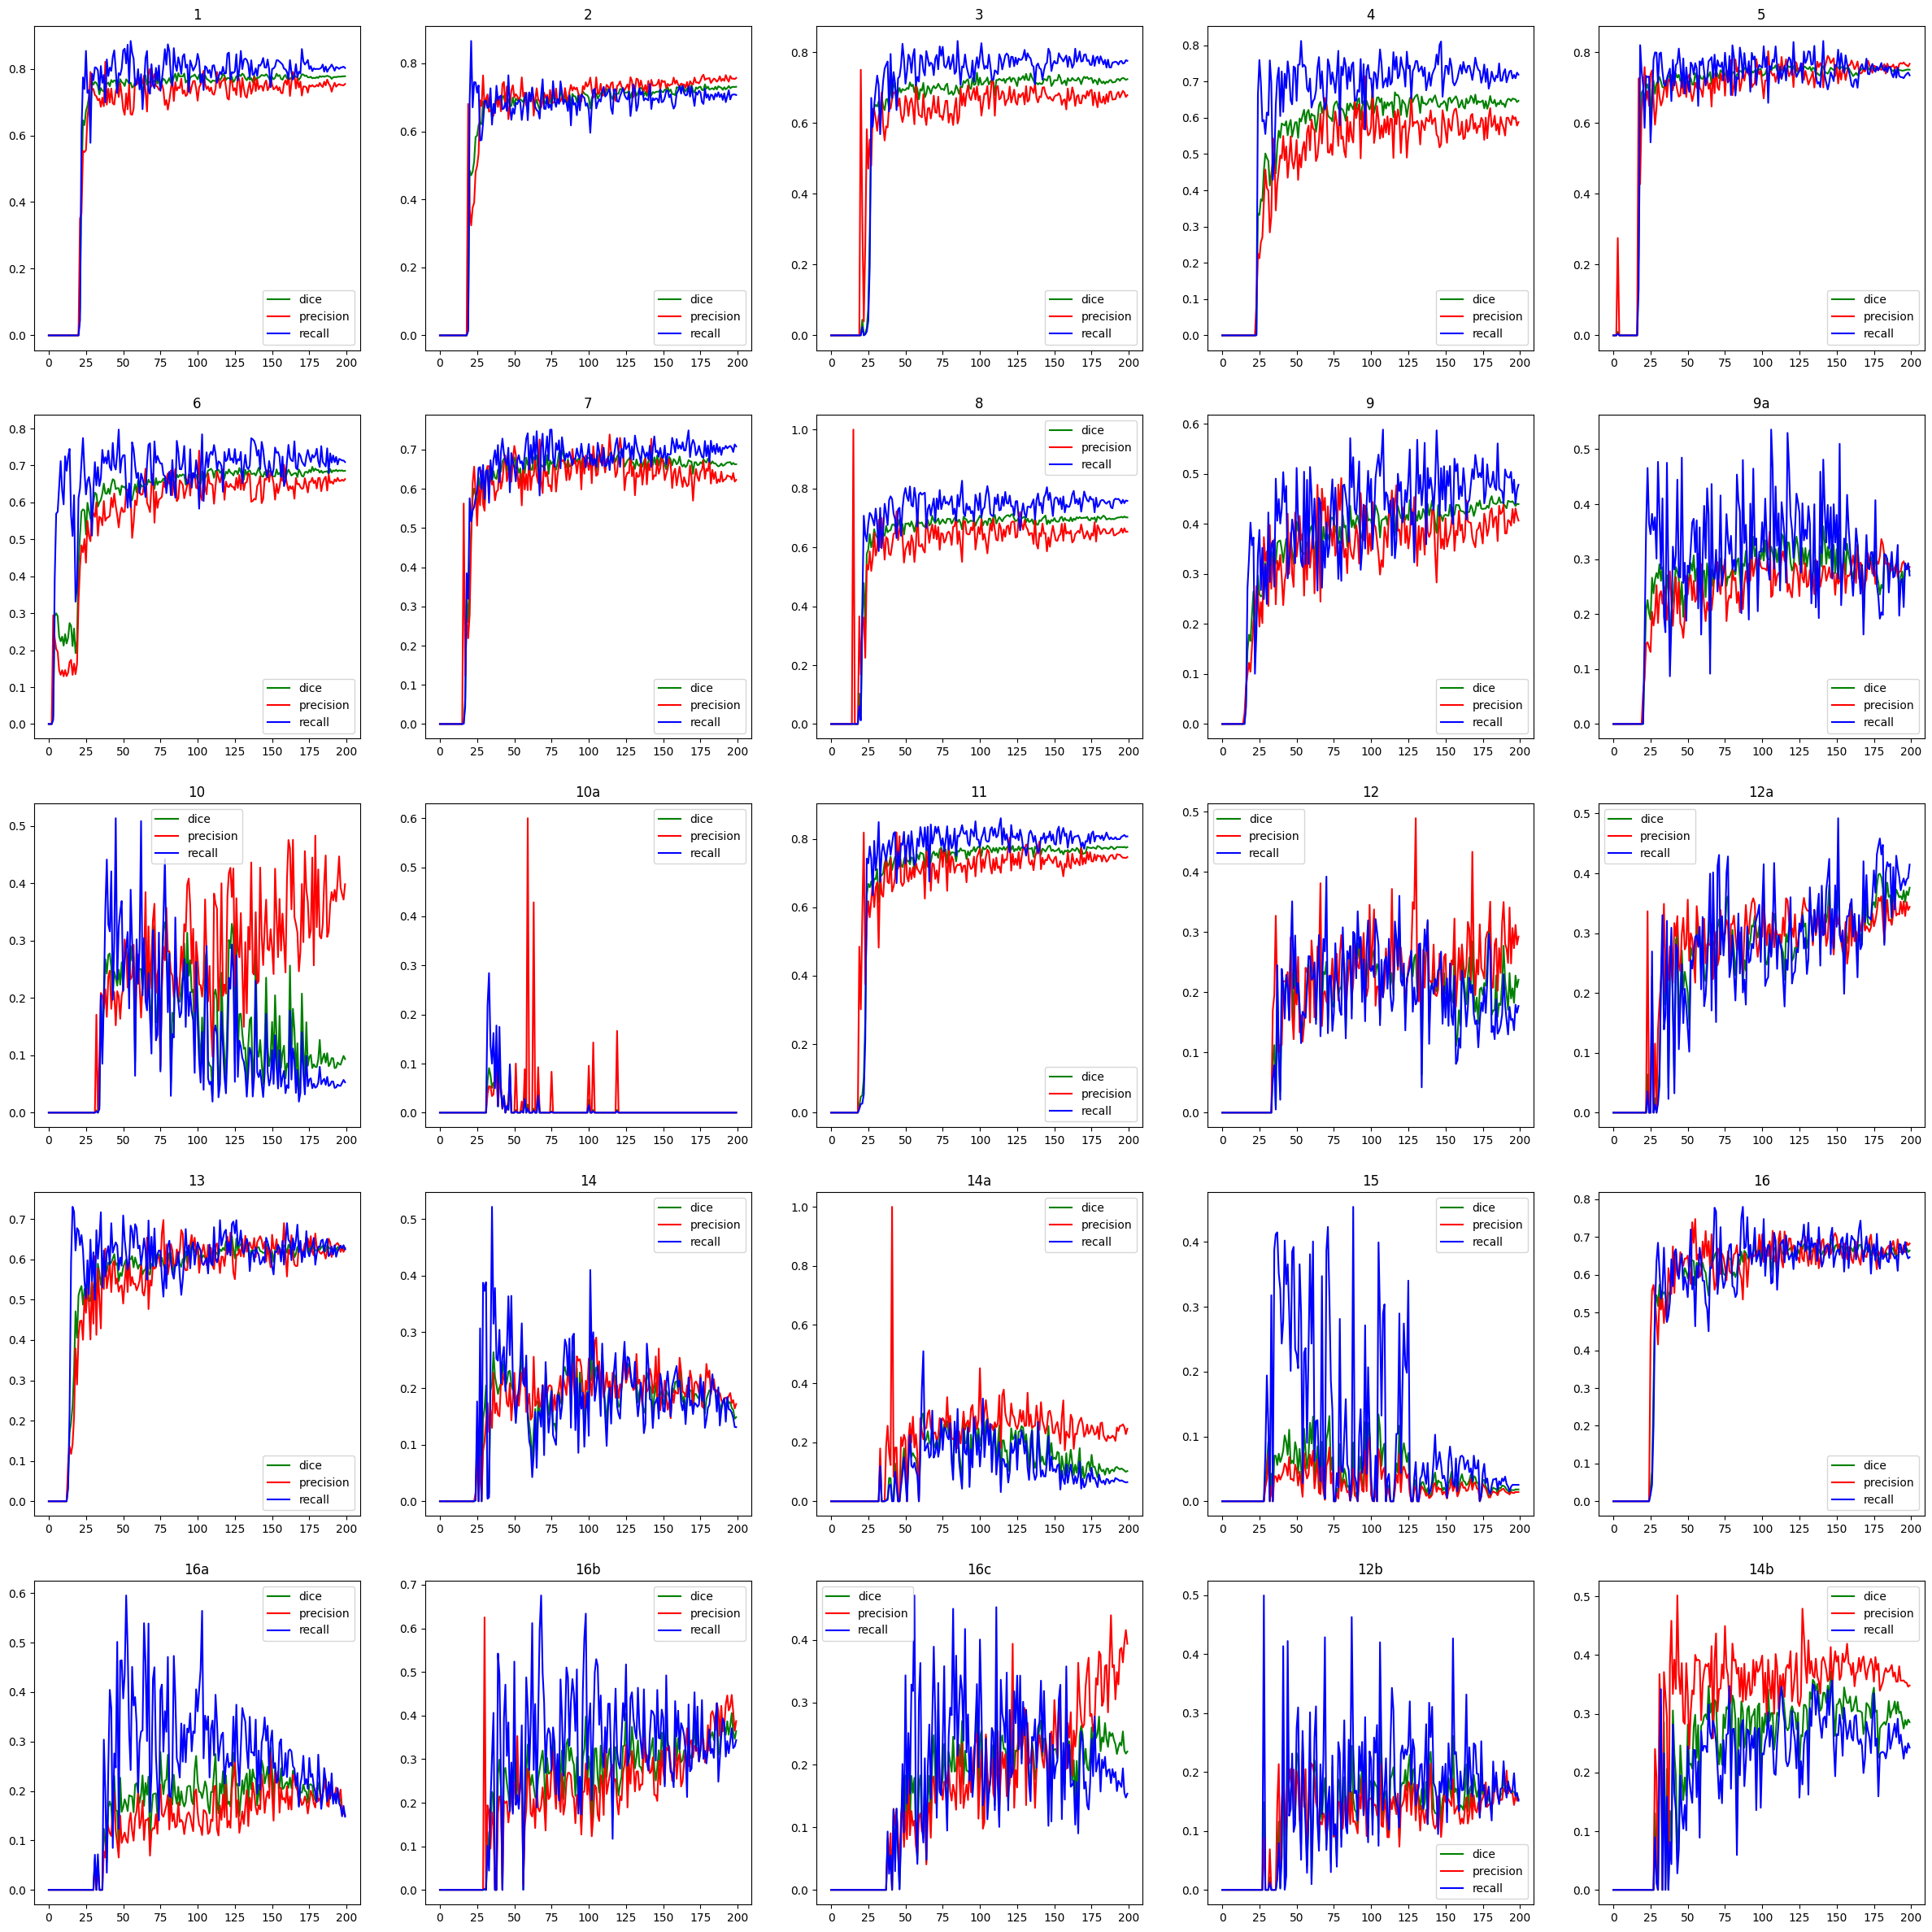

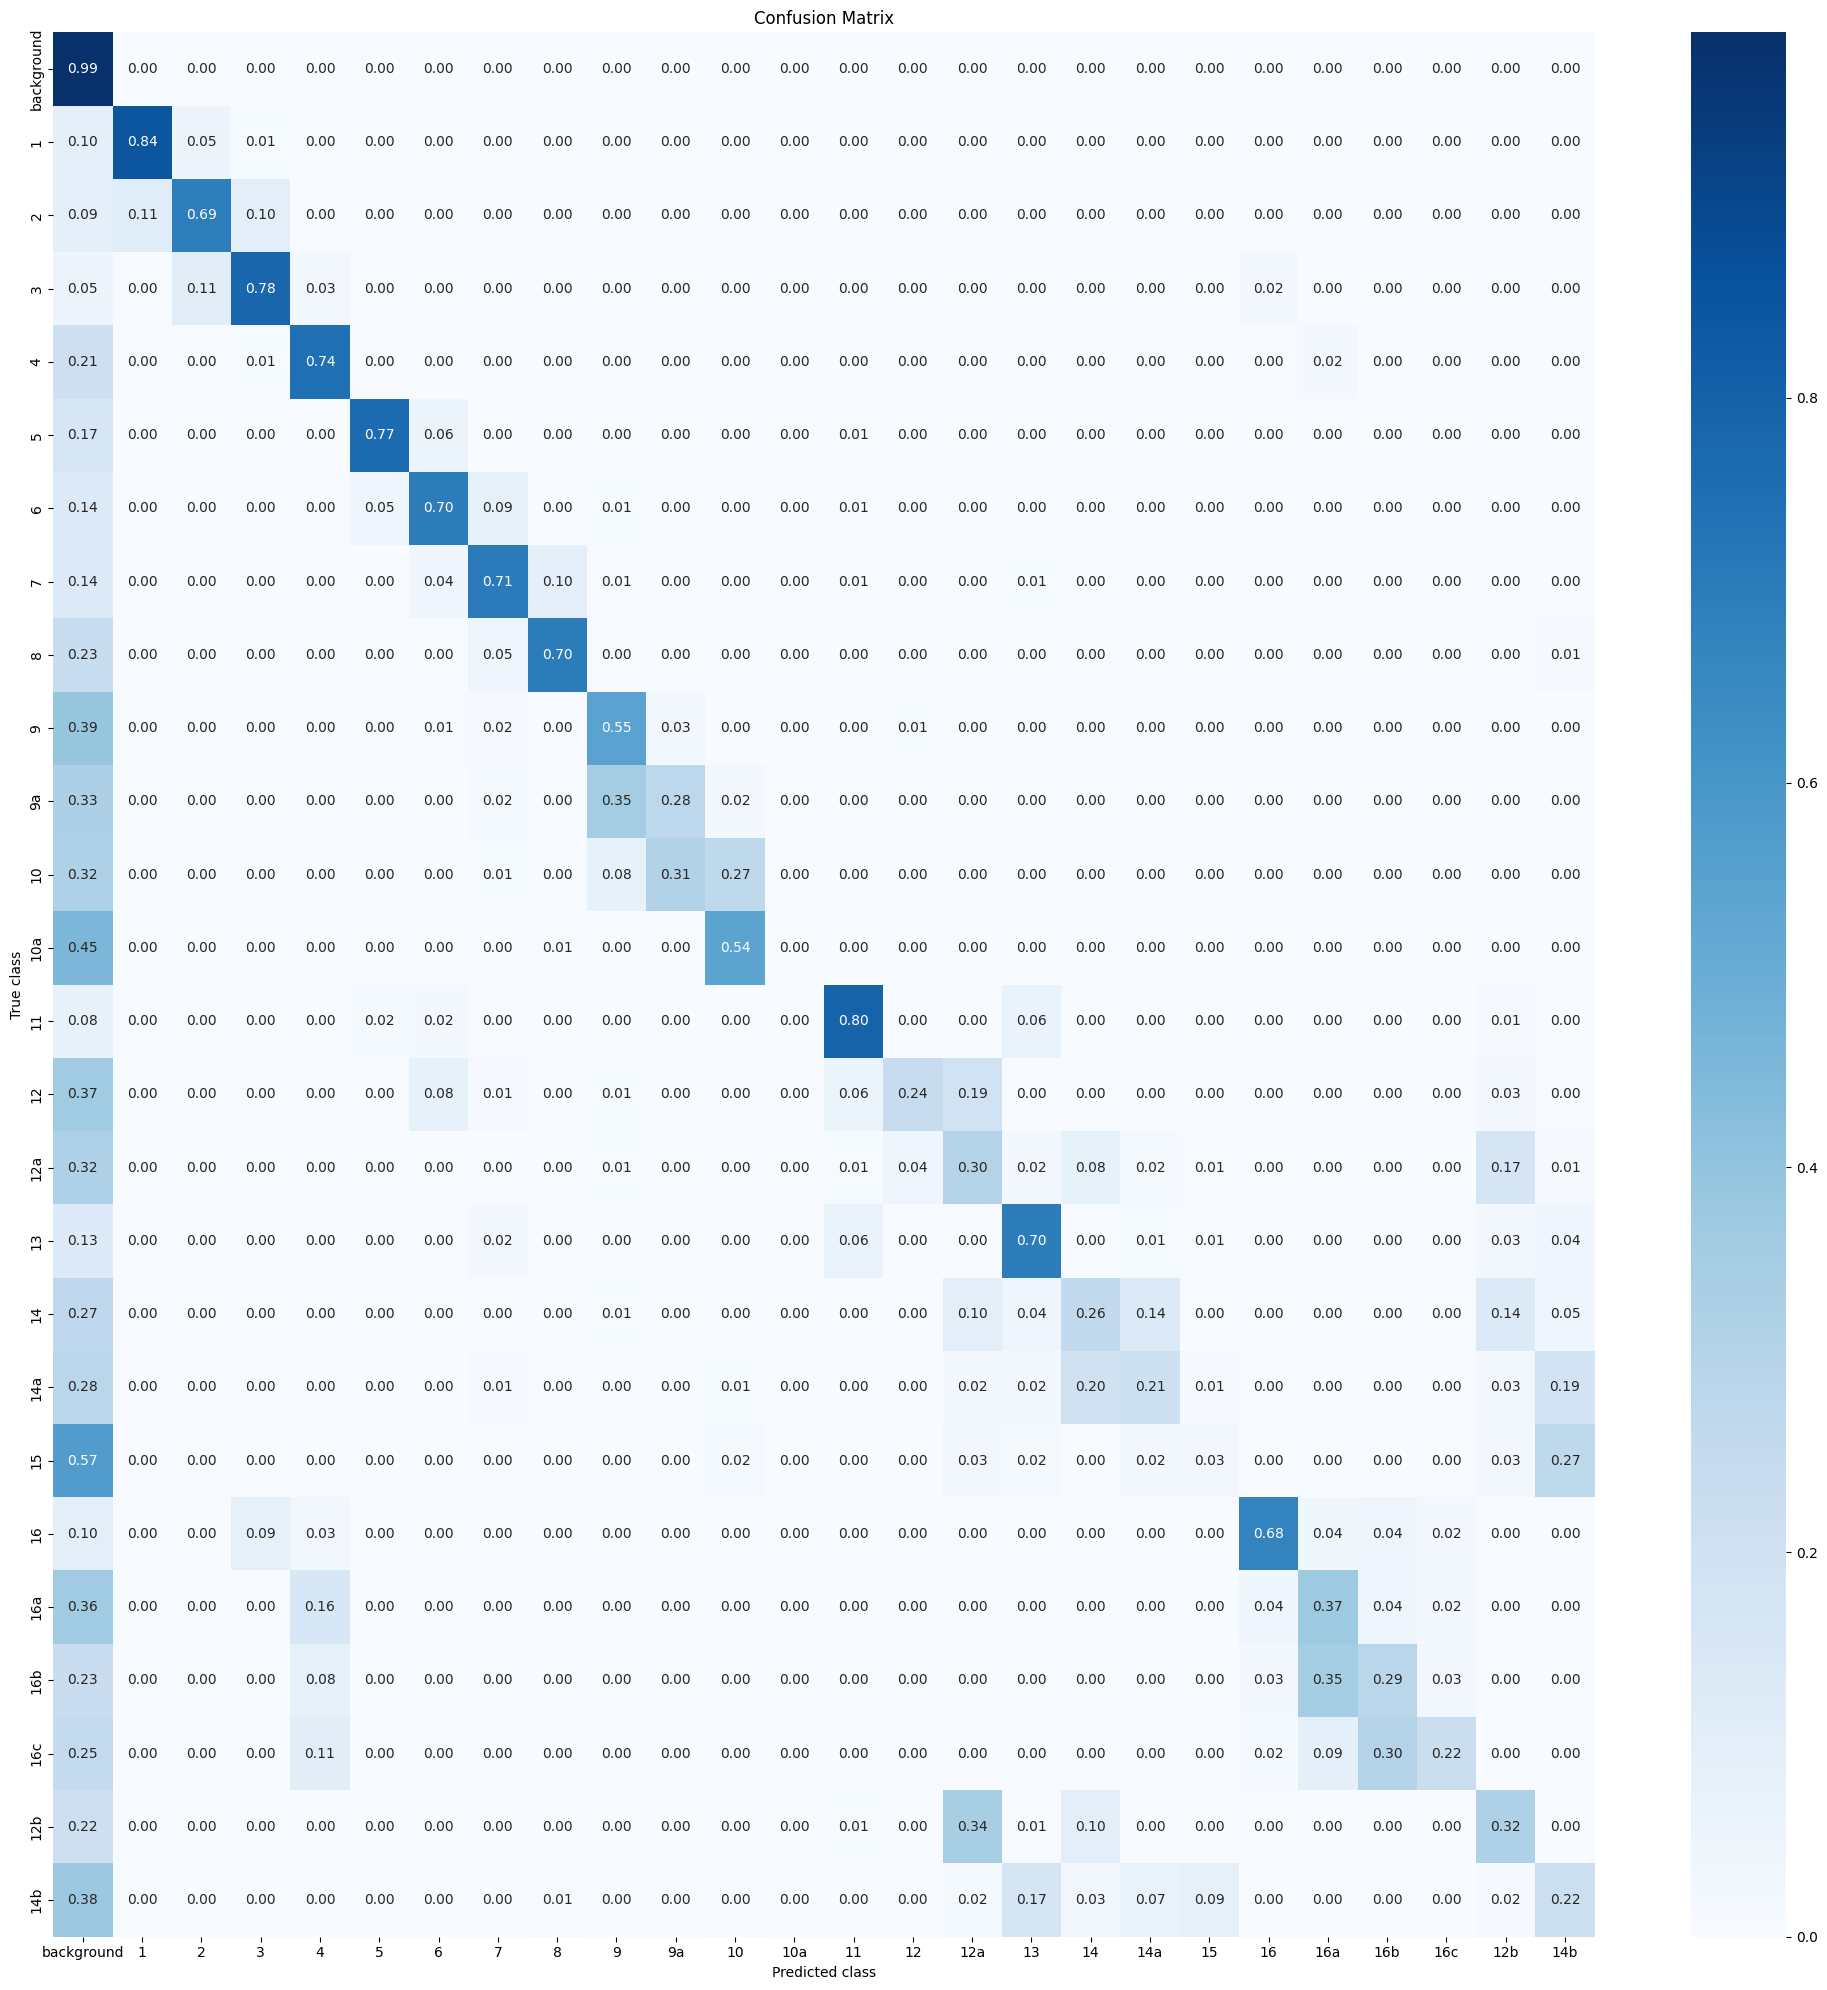

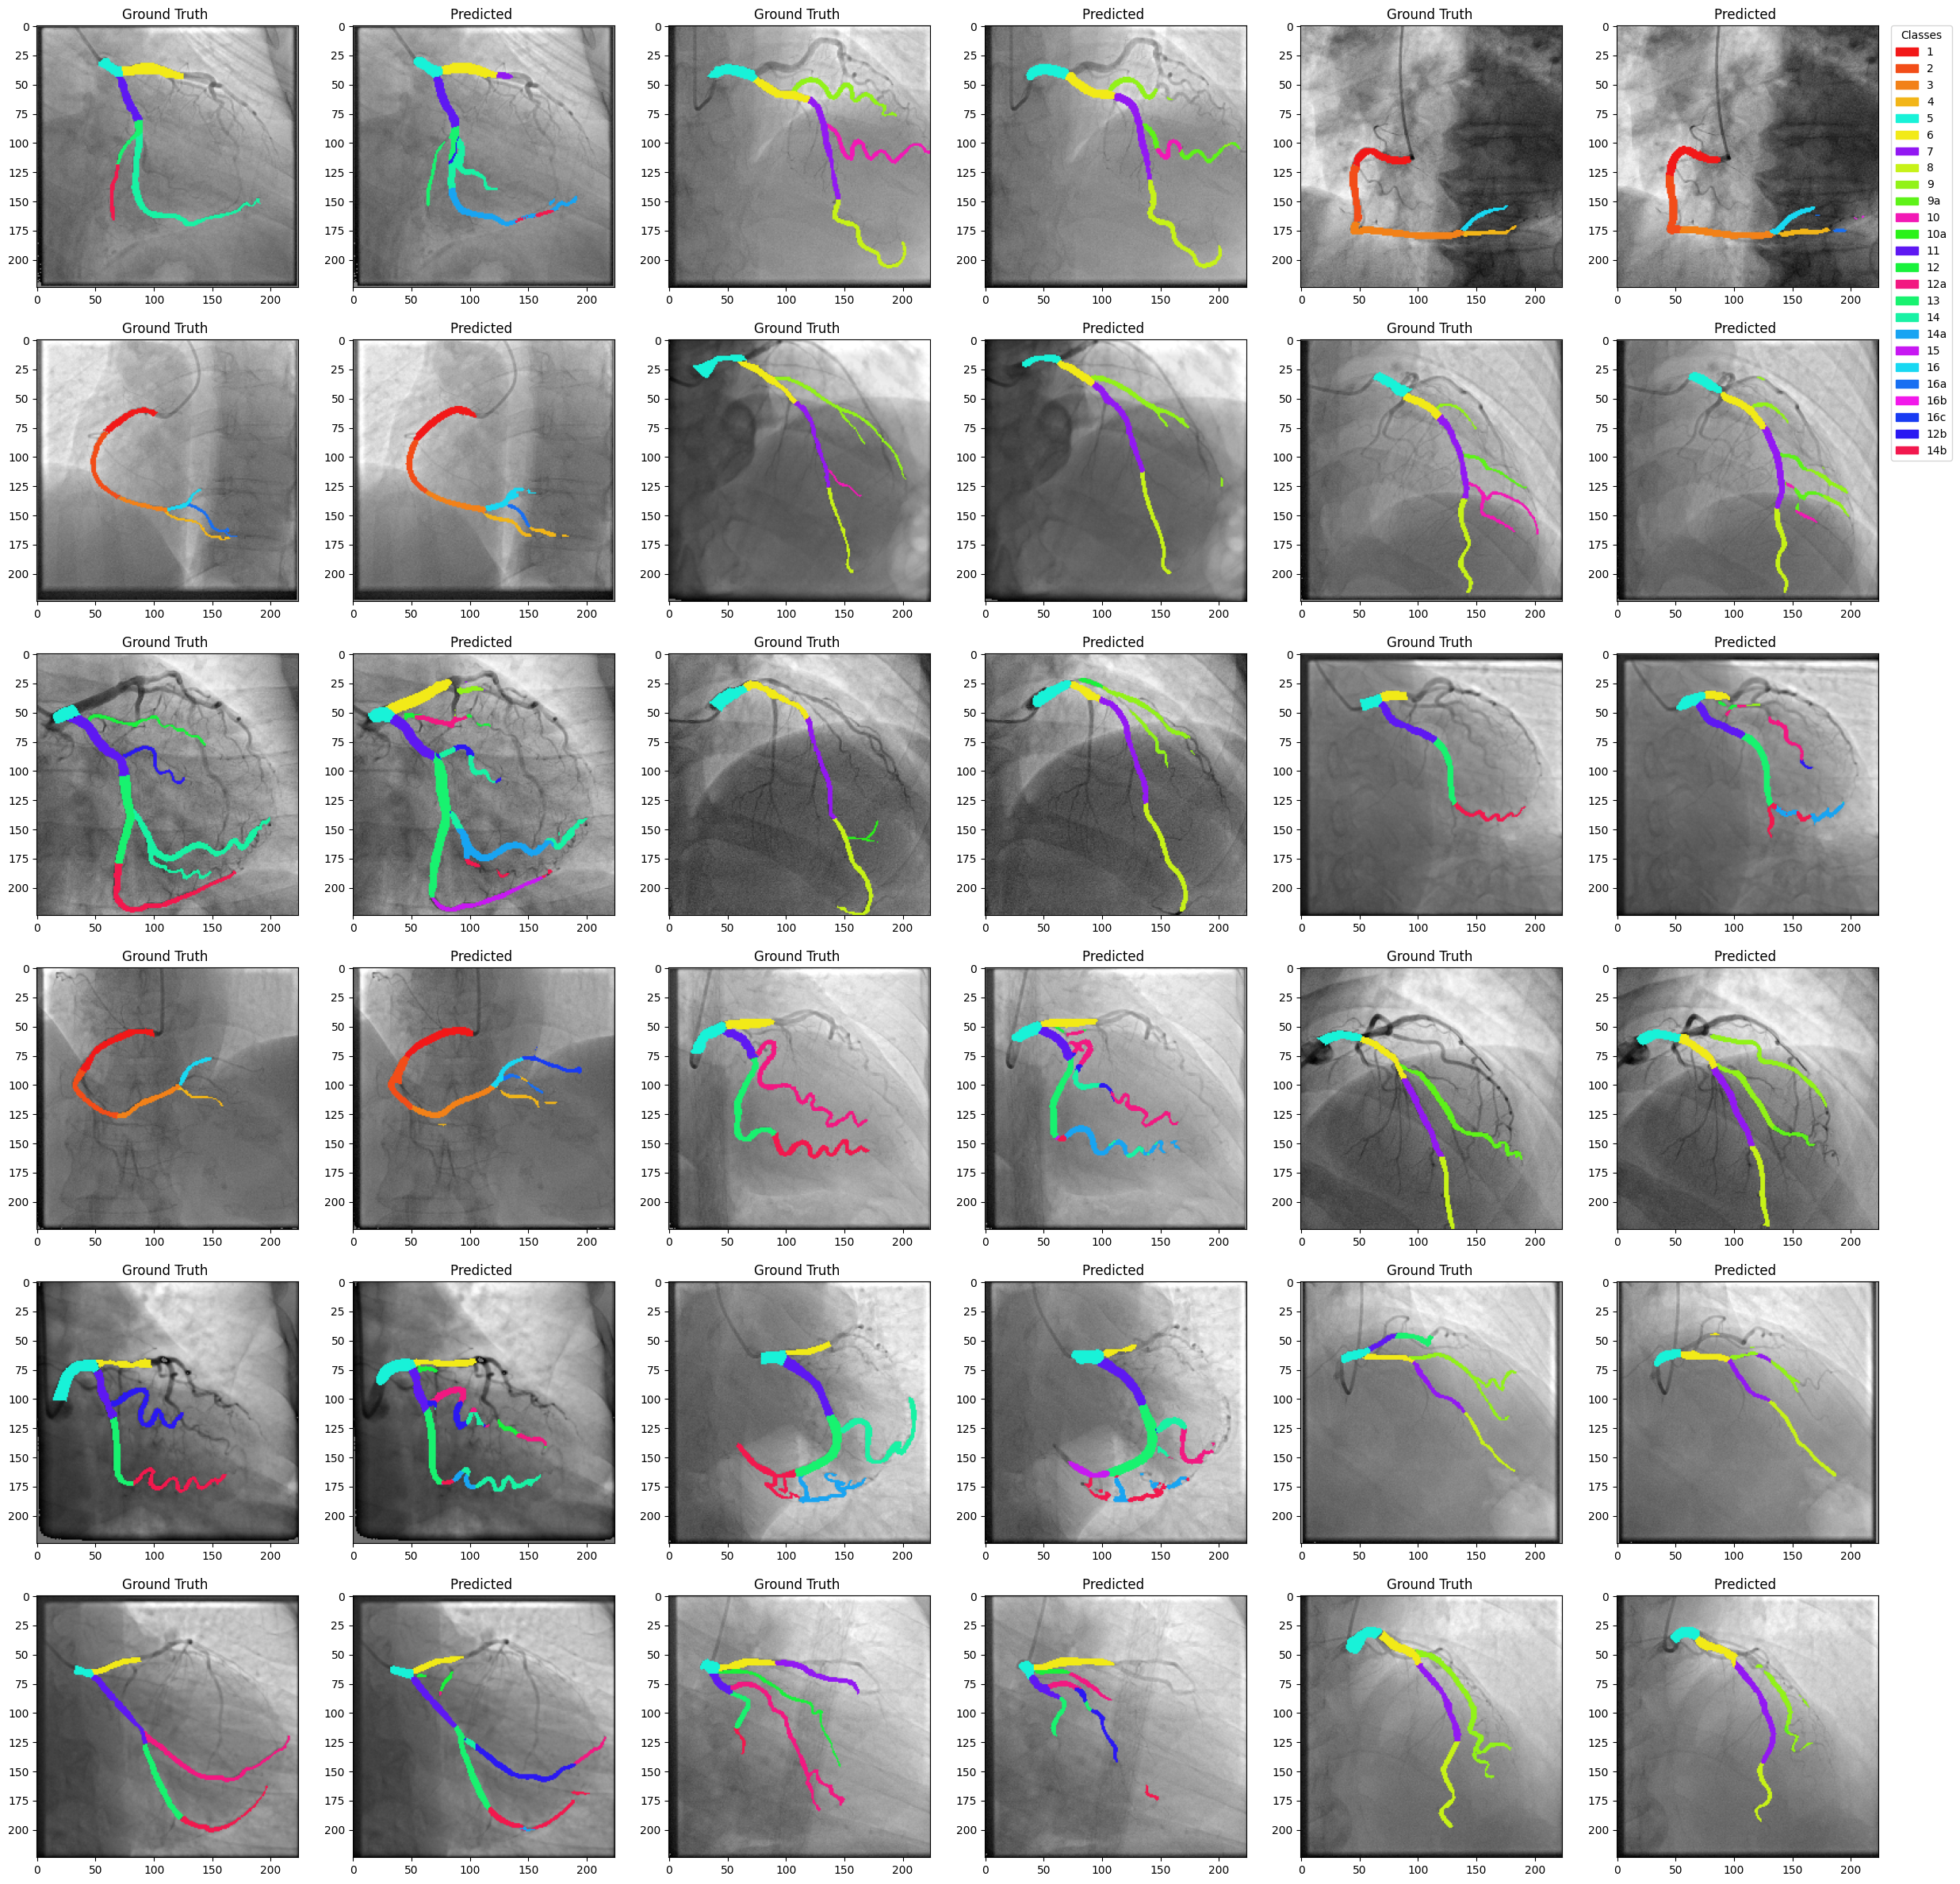

In [13]:
save_full_report(
    recorder= recorder , 
    output_base_path=args["output_base_path"],
    model=best_model,
    valid_loader=valid_loader,
    args=args,
    class_map=class_map,
    name=args["name"]
)